# Notebook 01: Long-run money growth and inflation

Core question: across countries, do higher long-run averages of money growth line up with higher long-run averages of inflation?

Quick scope:

- Inspired by Lucas (1996) / McCandless-Weber (1995).
- Data: `02_data/analysis_ready/macro_growth_merged.csv` (annual cross-country panel, through 2024).
- Main test: country-average inflation on country-average money growth, with `n_obs >= 30`.
- Extra checks: clean sample (`sample_low_inflation == 1`) and an auxiliary nominal-rate proxy check.

#### Data Input and Helper Function

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

MIN_LONGRUN_OBS = 30


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "02_data/analysis_ready/macro_growth_merged.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root with analysis-ready data.")


def fit_ols(data: pd.DataFrame, formula: str, robust: bool = False):
    model = smf.ols(formula, data=data)
    return model.fit(cov_type="HC1") if robust else model.fit()


def summarize_slope(fit, model_name: str, slope_var: str) -> dict:
    return {
        "model": model_name,
        "coef_m2_growth": float(fit.params[slope_var]),
        "p_value": float(fit.pvalues[slope_var]),
        "adj_r2": float(fit.rsquared_adj),
        "nobs": int(fit.nobs),
    }


def make_country_averages(data: pd.DataFrame, min_obs: int = MIN_LONGRUN_OBS) -> pd.DataFrame:
    country_avg = (
        data.groupby("country", as_index=False)
        .agg(
            m2_growth=("m2_growth", "mean"),
            inflation=("inflation", "mean"),
            gdp_growth=("gdp_growth", "mean"),
            n_obs=("year", "count"),
        )
    )
    return country_avg[country_avg["n_obs"] >= min_obs].copy()


def plot_regression(ax, data: pd.DataFrame, x: str, y: str, title: str, xlabel: str, ylabel: str) -> None:
    sns.regplot(data=data, x=x, y=y, scatter_kws={"alpha": 0.6}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


ROOT = find_project_root(Path.cwd().resolve())
PANEL_PATH = ROOT / "02_data/analysis_ready/macro_growth_merged.csv"
OUT_DIR = ROOT / "03_analysis_notebooks/exports/phase0"
OUT_DIR.mkdir(parents=True, exist_ok=True)
ROOT

PosixPath('/Users/stevenchung/Desktop/P12B_File/Monetary_Panel')

In [2]:
df = pd.read_csv(PANEL_PATH).rename(columns={"Country Name": "country"})

summary = pd.DataFrame(
    {
        "metric": ["rows", "countries", "year_min", "year_max"],
        "value": [
            len(df),
            df["country"].nunique(),
            int(df["year"].min()),
            int(df["year"].max()),
        ],
    }
)
summary

,metric,value
0,rows,4750
1,countries,160
2,year_min,1991
3,year_max,2024


#### First pass on Pooled OLS

In [3]:
pooled_specs = [
    ("pooled_inflation", "inflation ~ m2_growth", ["inflation", "m2_growth"]),
    ("pooled_gdp_growth", "gdp_growth ~ m2_growth", ["gdp_growth", "m2_growth"]),
]

## The results of these pooled OLS regressions are not the main focus of the analysis
## But it shows a positive relationship between M2 growth and inflation
## and M2 growth and GDP growth uncorrelated much, which is consistent with economic theory and prior empirical findings.
pooled_results = []
for model_name, formula, required_cols in pooled_specs:
    fit = fit_ols(df.dropna(subset=required_cols), formula, robust=True)
    pooled_results.append(summarize_slope(fit, model_name=model_name, slope_var="m2_growth"))

pooled_results = pd.DataFrame(pooled_results)
pooled_results

,model,coef_m2_growth,p_value,adj_r2,nobs
0,pooled_inflation,0.889125,8.828515e-71,0.686995,4749
1,pooled_gdp_growth,-0.000509,9.489811e-01,-0.000207,4749


### Major replication: long-run inflation-M2 relationship

In [4]:
country_avg_30 = make_country_averages(df)

longrun_specs = [
    (
        "longrun_inflation_country_avg",
        "inflation ~ m2_growth",
        ["inflation", "m2_growth"],
    ),
    (
        "longrun_gdp_country_avg",
        "gdp_growth ~ m2_growth",
        ["gdp_growth", "m2_growth"],
    ),
]

longrun_results = []
for model_name, formula, required_cols in longrun_specs:
    fit = fit_ols(country_avg_30.dropna(subset=required_cols), formula)
    longrun_results.append(summarize_slope(fit, model_name=model_name, slope_var="m2_growth"))

longrun_results = pd.DataFrame(longrun_results)
longrun_results

,model,coef_m2_growth,p_value,adj_r2,nobs
0,longrun_inflation_country_avg,0.951599,4.411391e-50,0.876037,108
1,longrun_gdp_country_avg,0.016277,4.840252e-01,-0.004759,108


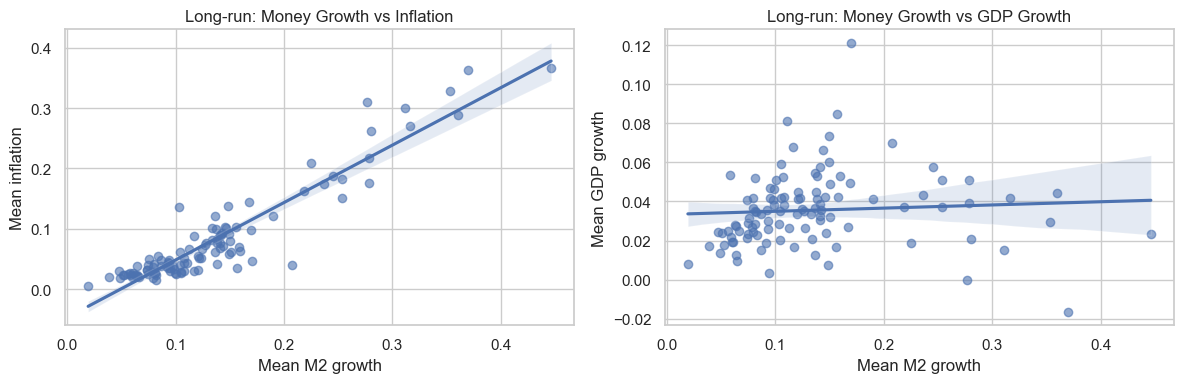

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_regression(
    axes[0],
    country_avg_30,
    x="m2_growth",
    y="inflation",
    title="Long-run: Money Growth vs Inflation",
    xlabel="Mean M2 growth",
    ylabel="Mean inflation",
)

plot_regression(
    axes[1],
    country_avg_30,
    x="m2_growth",
    y="gdp_growth",
    title="Long-run: Money Growth vs GDP Growth",
    xlabel="Mean M2 growth",
    ylabel="Mean GDP growth",
)

fig.tight_layout()
fig.savefig(OUT_DIR / "phase0_longrun_scatter.png", dpi=170)
plt.show()

In [6]:
exports = {
    "phase0_pooled_results.csv": pooled_results,
    "phase0_longrun_results.csv": longrun_results,
    "phase0_country_averages_n30.csv": country_avg_30,
    "phase0_sample_summary.csv": summary,
}

for filename, frame in exports.items():
    frame.to_csv(OUT_DIR / filename, index=False)

print("Saved Phase 0 outputs to:", OUT_DIR)

Saved Phase 0 outputs to: /Users/stevenchung/Desktop/P12B_File/Monetary_Panel/03_analysis_notebooks/exports/phase0


### Clean sample: Long-run relationship but on a smaller sample of country

Idea: if the inflation-M2 correlation in linear and homogenous everywhere, then smaller sample should result in similar estimated value. Other-wise, it implies that the inflation-M2 is state-dependent.

Clean sample (n>=30, n=83 countries)
M2->inflation: slope=0.5235 p=6.80e-15 R2=0.529
M2->GDP:       slope=0.2833 p=0.0000 R2=0.291


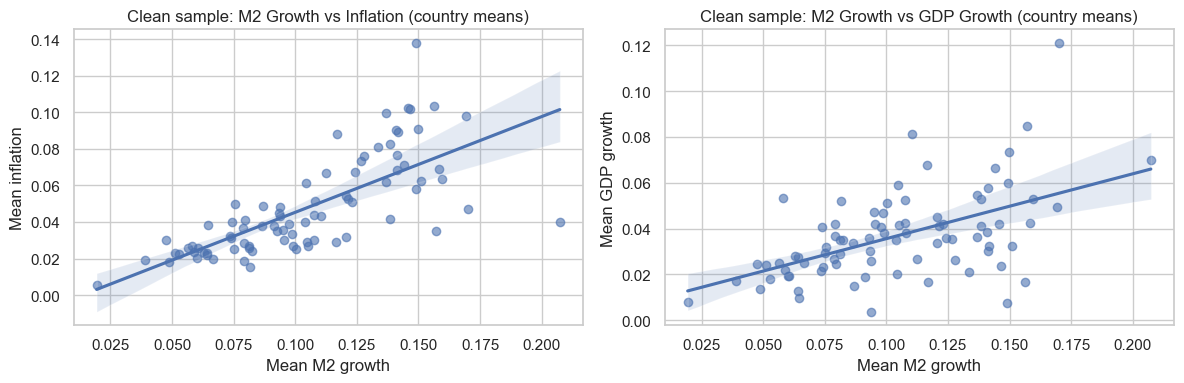

In [7]:
## Countries are kept only if flagged `sample_low_inflation == 1`
## which mean no annual inflation above 40%
# then the same long-run averaging and `n_obs >= 30` rule is applied.

clean = df[df["sample_low_inflation"] == 1].copy()
clean_avg_30 = make_country_averages(clean)

fit_inf_clean = fit_ols(
    clean_avg_30.dropna(subset=["inflation", "m2_growth"]),
    "inflation ~ m2_growth",
)
fit_gdp_clean = fit_ols(
    clean_avg_30.dropna(subset=["gdp_growth", "m2_growth"]),
    "gdp_growth ~ m2_growth",
)

print(f"Clean sample (n>={MIN_LONGRUN_OBS}, n={len(clean_avg_30)} countries)")
print(
    f"M2->inflation: slope={fit_inf_clean.params['m2_growth']:.4f}",
    f"p={fit_inf_clean.pvalues['m2_growth']:.2e}",
    f"R2={fit_inf_clean.rsquared:.3f}",
)
print(
    f"M2->GDP:       slope={fit_gdp_clean.params['m2_growth']:.4f}",
    f"p={fit_gdp_clean.pvalues['m2_growth']:.4f}",
    f"R2={fit_gdp_clean.rsquared:.3f}",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_regression(
    axes[0],
    clean_avg_30,
    x="m2_growth",
    y="inflation",
    title="Clean sample: M2 Growth vs Inflation (country means)",
    xlabel="Mean M2 growth",
    ylabel="Mean inflation",
)

plot_regression(
    axes[1],
    clean_avg_30,
    x="m2_growth",
    y="gdp_growth",
    title="Clean sample: M2 Growth vs GDP Growth (country means)",
    xlabel="Mean M2 growth",
    ylabel="Mean GDP growth",
)

fig.tight_layout()
plt.show()

### Interest rate and inflation: Practical Proxy as Supplmentary

A harmonized cross-country policy-rate panel is not in the current core dataset, so this notebook uses World Bank lending rates as a broad proxy for nominal rates. This provides a rough check, rather than a structural policy-rate test.

n=73 countries
M2->lending rate: slope=1.1820 p=0.0000 R2=0.390


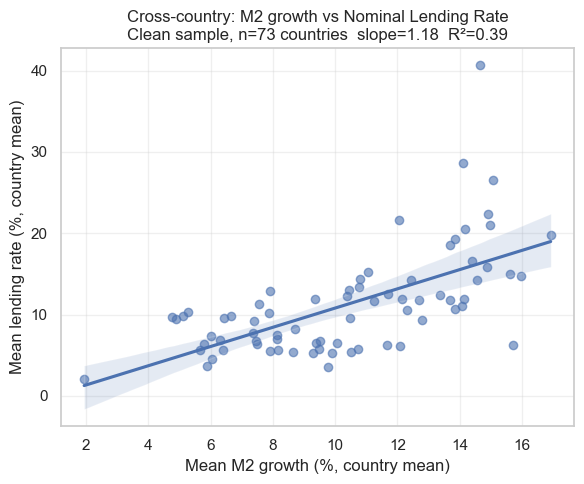

Note: lending rate includes bank spread above policy rate; slope can be dampened vs T-bill.


In [8]:
rates = pd.read_csv(ROOT / "02_data/supporting/intl_lending_rates.csv").rename(
    columns={"Country Name": "country"}
)

rate_avg = (
    rates[rates["country"].isin(clean["country"])]
    .groupby("country", as_index=False)
    .agg(rate_avg=("lending_rate_pct", "mean"))
)

ca_rate = clean_avg_30.merge(rate_avg, on="country").dropna(subset=["m2_growth", "rate_avg"]).copy()
ca_rate["m2_growth_pct"] = ca_rate["m2_growth"] * 100

fit_rate = fit_ols(ca_rate, "rate_avg ~ m2_growth_pct")
print(f"n={len(ca_rate)} countries")
print(
    f"M2->lending rate: slope={fit_rate.params['m2_growth_pct']:.4f}",
    f"p={fit_rate.pvalues['m2_growth_pct']:.4f}",
    f"R2={fit_rate.rsquared:.3f}",
)

fig, ax = plt.subplots(figsize=(6, 5))
plot_regression(
    ax,
    ca_rate,
    x="m2_growth_pct",
    y="rate_avg",
    title=(
        "Cross-country: M2 growth vs Nominal Lending Rate\n"
        f"Clean sample, n={len(ca_rate)} countries  "
        f"slope={fit_rate.params['m2_growth_pct']:.2f}  R²={fit_rate.rsquared:.2f}"
    ),
    xlabel="Mean M2 growth (%, country mean)",
    ylabel="Mean lending rate (%, country mean)",
)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print("Note: lending rate includes bank spread above policy rate; slope can be dampened vs T-bill.")